# Модель для прогнозирования оттока клиентов для сервиса доставки кофе

**Описание исследования:**

На рынке доставки кофе высокая конкуренция, поэтому привлечение нового клиента обходится в 5–7 раз дороже, чем удержание существующего. В последние месяцы Happy Beans Coffee столкнулись с проблемой: каждый месяц сервис теряет 10% клиентской базы, что напрямую снижает ежемесячную выручку. Из-за этого также неэффективно расходуется маркетинговый бюджет: он «работает вхолостую», не обеспечивая прироста клиентской базы.

**Цель исследования:**

Необходимо создать проект по прогнозированию оттока клиентов для исправления ситуации.

**Тип задачи:** обучение с учителем;

**Целевая переменная (Target):**

* churn — бинарный признак, где:
    * 1 — клиент уйдет (положительный класс, "positive").
    * 0 — клиент останется (отрицательный класс, "negative").
    
**Бизнес-контекст и цель:**
* Проблема: Ежемесячная потеря 10% клиентской базы, что приводит к прямому снижению выручки и неэффективному расходованию маркетингового бюджета.
* Цель бизнеса: Снизить отток клиентов и оптимизировать маркетинговые расходы за счет своевременного и целенаправленного удержания клиентов, склонных к уходу.
* Цель ML: Построить модель, которая для каждого клиента в начале месяца рассчитывает вероятность его оттока в течение этого месяца. Это позволит службе удержания клиентов сфокусировать свои усилия и ресурсы (персональные предложения, скидки, опросы) на наиболее "рисковой" группе.

**Критерии успешности и метрики качества:**
* Учитывая сильный дисбаланс классов, выбор метрик является критически важным.
* Основная метрика: F2-Score.

Обоснование: Метрика F-мра (F-beta) является гармоническим средним между Precision (точность) и Recall (полнота). Мы используем F2-Score, который в два раза больше весит Recall по сравнению с Precision.\

Почему это важно: В нашей задаче ложнопропущенный уходящий клиент (False Negative) стоит бизнесу гораздо дороже, чем ложное срабатывание (False Positive). Если мы пометим лояльного клиента как "уходящего" и потратим на него необязательные 100 рублей, это незначительные потери. Но если мы пропустим уходящего клиента, бизнес теряет весь его будущий LTV (Lifetime Value), который может составлять тысячи рублей.

Дополнительные ключевые метрики:

Precision-Recall AUC (PR-AUC): Это основная метрика для оценки качества модели на несбалансированных данных. Она фокусируется на качестве предсказания положительного класса (уходящих клиентов) и не зависит от доли отрицательного класса, в отличие от ROC-AUC. Цель — максимизировать PR-AUC.

ROC-AUC: Показывает общую способность модели ранжировать клиентов (разделять уходящих и остающихся). Является хорошей дополняющей метрикой, но в условиях сильного дисбаланса может давать излишне оптимистичную оценку. Цель — значение выше 0.9.

Матрица ошибок (Confusion Matrix): Для визуальной интерпретации количества True Positive, False Positive, True Negative и, что самое важное, False
Negative.

Отвергаемые метрики:

Accuracy (Точность): Бесполезна в условиях дисбаланса.

Ожидаемый выход модели: Модель должна возвращать для каждого клиента вероятность принадлежности к классу 1 (вероятность оттока). Это позволит не только бинарно классифицировать клиентов, но и ранжировать их по степени риска.

**План работы:**

**Этап 1.** Подготовка среды и библиотек

**Этап 2.** Первичный анализ данных

**Этап 3.** Предобработка данных

**Этап 4.** Обучение модели

**Этап 5.** Создание новых признаков

**Этап 6.** Эксперименты с гиперпараметрами

**Этап 7.** Подготовка финальной модели

**Этап 8.** Отчёт о проделанной работе

**Этап 9.** Сохранение модели для продакшена

**Исходные данные:**

* `user_id` — идентификатор пользователя.
* `days_since_last_order` — количество дней, прошедших с последнего заказа.
* `order_frequency_month` — среднее число заказов в месяц.
* `order_frequency_week` — среднее число заказов в неделю.
* `avg_order_value` — средний чек, в рублях.
* `median_order_value` — медианный чек, в рублях.
* `total_spent_last_month` — сумма заказов за последний месяц.
* `total_spent_last_week` — сумма заказов за последнюю неделю.
* `discount_usage_rate` — доля заказов со скидкой за последний месяц.
* `last_coffee_type` — сорт кофе, купленный пользователем в последний раз на момент сбора данных.
* `preferred_roast` — предпочитаемый тип обжарки.
* `milk_preference` — предпочитаемый тип молока.
* `seasonal_menu_tried` — отметка о том, пробовал ли пользователь новейшее сезонное меню.
* `coffee_bean_origin` — страна происхождения зерна.
* `last_drink_size` — размер последнего заказа, совершённого на момент сбора данных.
* `subscription_status` — тип подписки пользователя.
* `app_opens_per_week` — сколько раз за неделю пользователь в среднем открывал приложение доставки кофе.
* `notifications_enabled` — включены ли у пользователя уведомления.
* `review_rating_last_10` — средняя оценка последних на момент сбора данных десяти заказов клиента.
* `review_rating_last_1` — оценка последнего на момент сбора данных заказа клиента.
* `app_crashes_last_month` — сколько раз приложение зависало за последний месяц.
* `seasons` — текущее время года.
* `days_since_last_promo` — сколько дней прошло с последнего использования акции или промокода.
* `phone_type` — тип устройства, с которого пользователь чаще всего совершал покупки.
* `coffee_preference_change` — менялись ли вкусовые предпочтения пользователя.
* `geo_id` — идентификатор региона пользователя.
* `churn` — перестал ли пользователь пользоваться сервисом.

## Этап 1. Подготовка среды и библиотек

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
!pip install phik -q
from phik import phik_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import average_precision_score, precision_recall_curve, log_loss
from sklearn.metrics import accuracy_score, roc_auc_score


from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import pickle

In [2]:
RANDOM_STATE = 42

In [3]:
df = pd.read_csv('https://code.s3.yandex.net/datasets/coffee_churn_dataset.csv', sep=',', decimal=".")

In [4]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Этап 2. Первичный анализ данных

In [5]:
df.head()

,user_id,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,last_coffee_type,...,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,seasons,days_since_last_promo,phone_type,coffee_preference_change,geo_location,churn
0,user_00318,0.0,12.942519,NaN,316.833872,260.645090,3089.991009,NaN,0.337031,blend,...,1.0,5.176792,3.302238,NaN,summer,6.0,android,0.0,geo_75,1
1,user_07234,2.0,1.569146,0.214494,780.135158,540.597850,998.380941,107.369409,0.547659,arabica,...,1.0,4.392991,NaN,0.0,autumn,16.0,ios,0.0,geo_95,0
2,user_04816,11.0,2.996666,0.771864,682.636256,471.494559,1328.140204,392.600011,0.120258,arabica,...,1.0,4.977712,4.379219,0.0,spring,11.0,web,1.0,geo_25,0
3,user_04419,0.0,4.299255,1.210480,2115.487425,708.529812,2999.628366,1084.352054,NaN,robusta,...,1.0,3.712526,3.043618,0.0,summer,3.0,android,0.0,geo_2,0
4,user_09698,3.0,7.249864,1.761027,3519.602170,1199.372894,8377.729478,2551.775211,0.074990,robusta,...,0.0,4.528271,5.642993,1.0,winter,14.0,ios,0.0,geo_19,1


In [6]:
df.info()
dff = df.copy()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   user_id                   10450 non-null  object 
 1   days_since_last_order     9505 non-null   float64
 2   order_frequency_month     9850 non-null   float64
 3   order_frequency_week      10062 non-null  float64
 4   avg_order_value           9867 non-null   float64
 5   median_order_value        9619 non-null   float64
 6   total_spent_last_month    10156 non-null  float64
 7   total_spent_last_week     9506 non-null   float64
 8   discount_usage_rate       10053 non-null  float64
 9   last_coffee_type          10192 non-null  object 
 10  preferred_roast           10334 non-null  object 
 11  milk_preference           9782 non-null   object 
 12  seasonal_menu_tried       9461 non-null   float64
 13  coffee_bean_origin        9768 non-null   object 
 14  last_d

In [7]:
df.describe()

,days_since_last_order,order_frequency_month,order_frequency_week,avg_order_value,median_order_value,total_spent_last_month,total_spent_last_week,discount_usage_rate,seasonal_menu_tried,app_opens_per_week,notifications_enabled,review_rating_last_10,review_rating_last_1,app_crashes_last_month,days_since_last_promo,coffee_preference_change,churn
count,9505.000000,9850.000000,10062.000000,9867.000000,9619.000000,10156.000000,9506.000000,10053.000000,9461.000000,9554.000000,9913.000000,9757.000000,9593.000000,9729.000000,9719.000000,9840.000000,10450.000000
mean,4.394214,4.025666,0.930686,1063.741207,452.651500,1946.132979,413.004760,0.284446,0.701194,11.330895,0.753052,4.206709,4.022460,1.013362,14.554584,0.192480,0.060191
std,4.858757,2.826144,0.657261,707.713396,258.657571,2370.619590,445.634902,0.158735,0.457759,14.528887,0.431258,0.782212,1.207883,1.010342,15.308869,0.394268,0.237852
min,0.000000,0.011046,-0.169131,-32.075932,-10.353340,-43.716463,-2290.559468,0.002162,0.000000,0.000000,0.000000,1.415526,-0.897000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.937767,0.445185,552.898663,262.908598,629.680382,136.565833,0.159884,0.000000,6.313628,1.000000,3.675543,3.214157,0.000000,4.000000,0.000000,0.000000
50%,3.000000,3.381094,0.784839,898.643524,406.456818,1300.409757,288.277327,0.264583,1.000000,9.228383,1.000000,4.203555,3.990032,1.000000,10.000000,0.000000,0.000000
75%,6.000000,5.439363,1.262350,1406.332153,590.418070,2481.650495,549.699420,0.387056,1.000000,12.726649,1.000000,4.717292,4.845225,2.000000,20.000000,0.000000,0.000000
max,40.000000,27.389318,6.302624,5901.965278,2189.101644,79298.849570,8615.988952,0.887301,1.000000,224.587876,1.000000,7.384425,8.558443,7.000000,140.000000,1.000000,1.000000


In [8]:
def show_missing_stats(temp0):
    """
    Функция для статистики пропущенных значений.
    """
    missing_stats = pd.DataFrame({
        'Количество пропусков': temp0.isna().sum(),
        'Доля пропусков': temp0.isnull().mean()
    })
    
    if missing_stats.empty:
        return 'Пропусков в данных нет'
    
    return (missing_stats.style.format({'Доля пропусков': '{:.4f}'}).background_gradient(cmap='coolwarm'))
show_missing_stats(df)

,Количество пропусков,Доля пропусков
user_id,0,0.0000
days_since_last_order,945,0.0904
order_frequency_month,600,0.0574
order_frequency_week,388,0.0371
avg_order_value,583,0.0558
median_order_value,831,0.0795
total_spent_last_month,294,0.0281
total_spent_last_week,944,0.0903
discount_usage_rate,397,0.0380
last_coffee_type,258,0.0247


In [9]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
duplicates_count = df.duplicated().sum()
print(f'Количество полных дубликатов: {duplicates_count}')
print(f'Процент дубликатов: {duplicates_count/len(df) * 100:.2f}%')

Количество полных дубликатов: 0
Процент дубликатов: 0.00%


In [10]:
# неполные дублиаты по пользователю
user_dups = df.duplicated(subset=['user_id'], keep='first').sum()
print(f"Дубликаты по user_id: {user_dups} ({user_dups/len(df)*100:.2f}%)")

Дубликаты по user_id: 0 (0.00%)


**Промежуточный вывод 2.1:**
* Датасет `/datasets/coffee_churn_dataset.csv` содержит 27 столбцов и 10450 строк, в которых содержится информация о клиентах, объем данных -  2.2+ MB;
* Пропусков много, они встречаются во всех столбцах, кроме `user_id` и `churn` (целевая переменная);
* Столбцы носят корректные названия, подходящие для анализа данных, они приведены к нижнему регистру и виду snake case, но с информации о данных столбец с идентификатором региона пользователя называется `geo_location`, а не `geo_id`, смысл не меняется, поэтому не будем переименовывать столбец;
* Представленные данные хранятся в: object, float64 и int64. Носят корректный тип данных;
* Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию;
* Частота заказов составляет около 4 месяцев;
* Средний чек у клиентов около 1064 руб, а медианный чек ниже 453 руб, это говорит о ассиметрии, есть крупные заказы.

In [11]:
df['churn'].describe()

count    10450.000000
mean         0.060191
std          0.237852
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: churn, dtype: float64

In [12]:
df['churn'].value_counts(normalize=True)

0    0.939809
1    0.060191
Name: churn, dtype: float64

In [13]:
df.columns = df.columns.str.lower().str.replace(' ', '_')
categorical_cols = [
    'last_coffee_type', 'preferred_roast', 'milk_preference',
    'coffee_bean_origin', 'last_drink_size', 'subscription_status',
    'seasons', 'phone_type', 'user_id', 'order_frequency_week', 'median_order_value', 'total_spent_last_week',
    'geo_location'
]

In [14]:
summary = pd.DataFrame({
    'Признак': categorical_cols,
    'Уникальных': [df[col].nunique() for col in categorical_cols],
    'Пропуски (%)': [f"{df[col].isna().mean()*100:.1f}" for col in categorical_cols],
    'Топ-категория': [df[col].mode()[0] if not df[col].mode().empty else 'N/A' for col in categorical_cols],
    'Доля топ-категории (%)': [
        f"{df[col].value_counts(normalize=True).iloc[0]*100:.1f}" 
        for col in categorical_cols
    ]
})

print(summary.to_string(index=False))

              Признак  Уникальных Пропуски (%) Топ-категория Доля топ-категории (%)
     last_coffee_type           3          2.5       arabica                   60.2
      preferred_roast           3          1.1        medium                   33.5
      milk_preference           6          6.4         whole                   29.4
   coffee_bean_origin           6          6.5      ethiopia                   17.3
      last_drink_size           3          4.8        medium                   49.5
  subscription_status           4          9.0          none                   40.0
              seasons           4          6.5        spring                   25.7
           phone_type           3          3.2       android                   45.6
              user_id       10450          0.0    user_00000                    0.0
 order_frequency_week        9625          3.7     -0.005598                    0.0
   median_order_value        9201          8.0    188.717923                

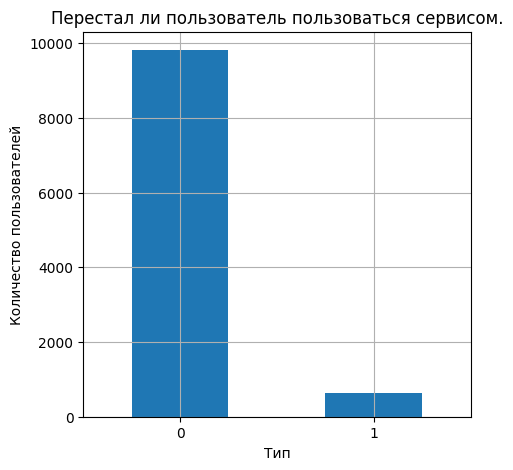

In [15]:
plt.figure(figsize = (5, 5))

df['churn'].value_counts().plot(
    kind='bar',
    rot=0,
    title='Перестал ли пользователь пользоваться сервисом.',
    legend=False
)
plt.xlabel('Тип')
plt.ylabel('Количество пользователей')
plt.grid()
plt.show()

Наблюдается сильный дисбаланс в целевой переменной (таргете). Он делает точность Accuracy бесполезной метрикой в данном случае. Метрика будет вводить в заблуждение (модель может достичь 90% точности, просто всегда предсказывая класс 0).

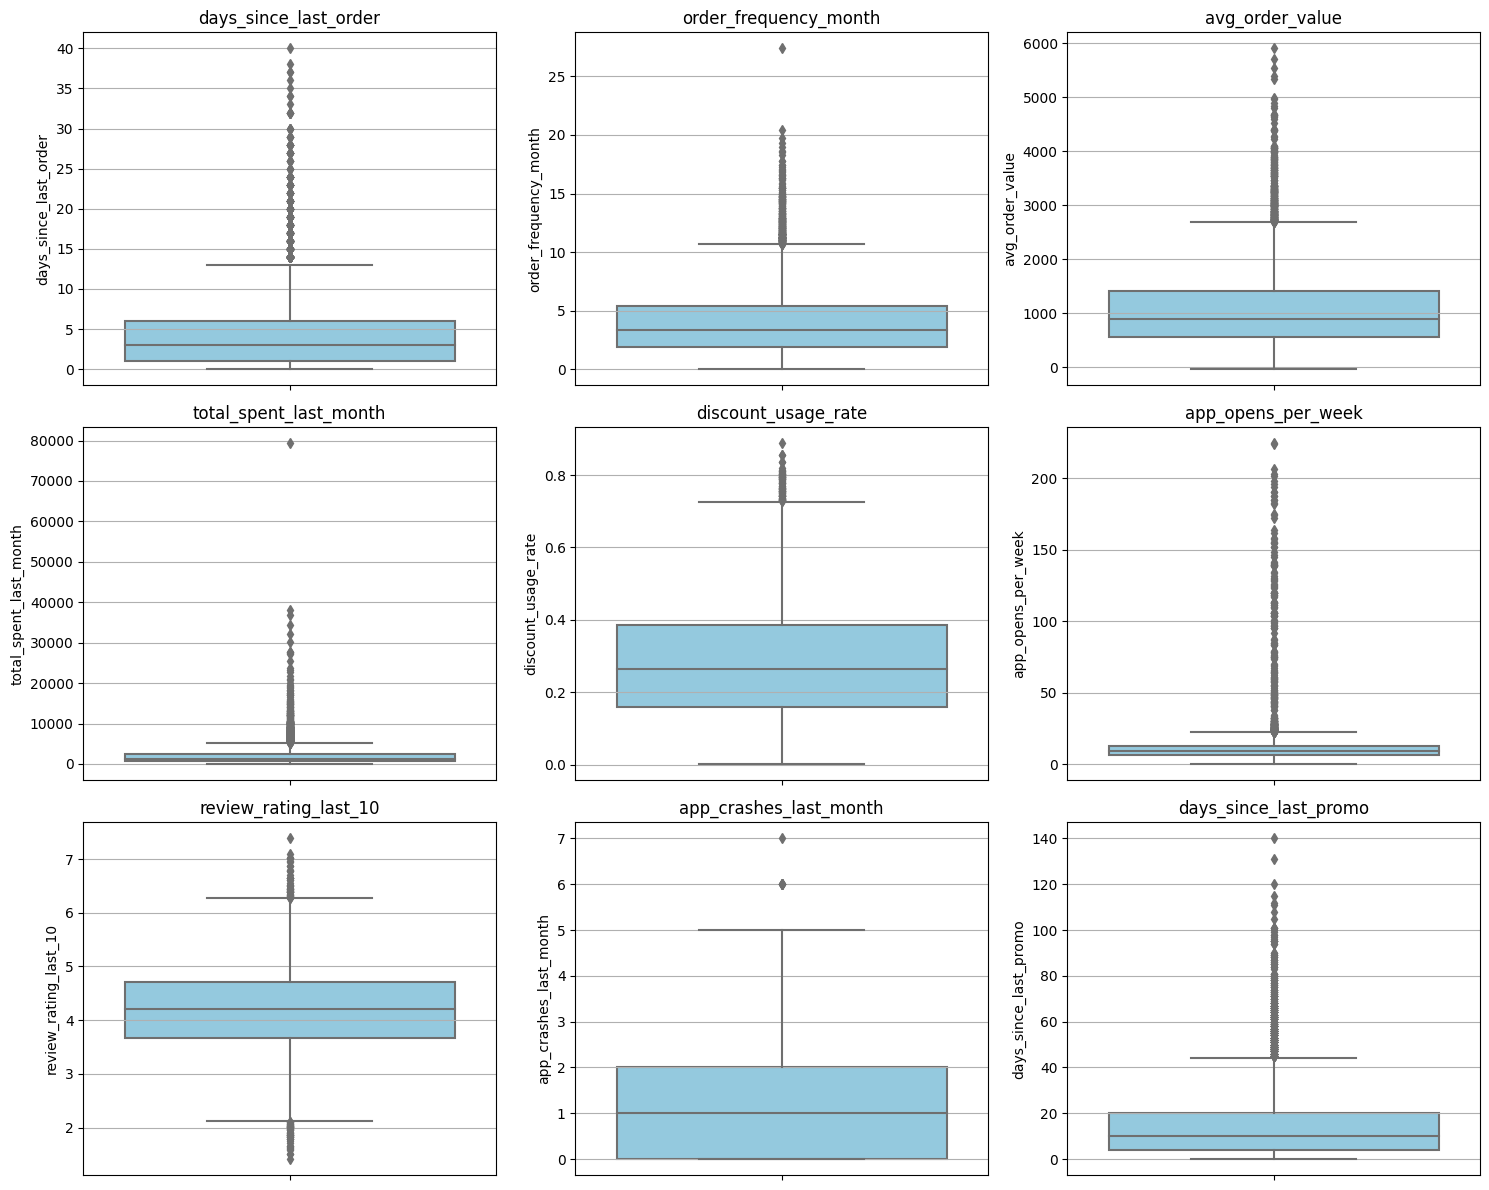

In [16]:
numerical_cols = [
    'days_since_last_order', 'order_frequency_month', 'avg_order_value',
    'total_spent_last_month', 'discount_usage_rate', 'app_opens_per_week',
    'review_rating_last_10', 'app_crashes_last_month', 'days_since_last_promo'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if col in df.columns:
        sns.boxplot(data=df, y=col, ax=axes[idx], color='skyblue')
        axes[idx].set_title(f'{col}')
        axes[idx].grid(axis='y')

plt.tight_layout()
plt.show()

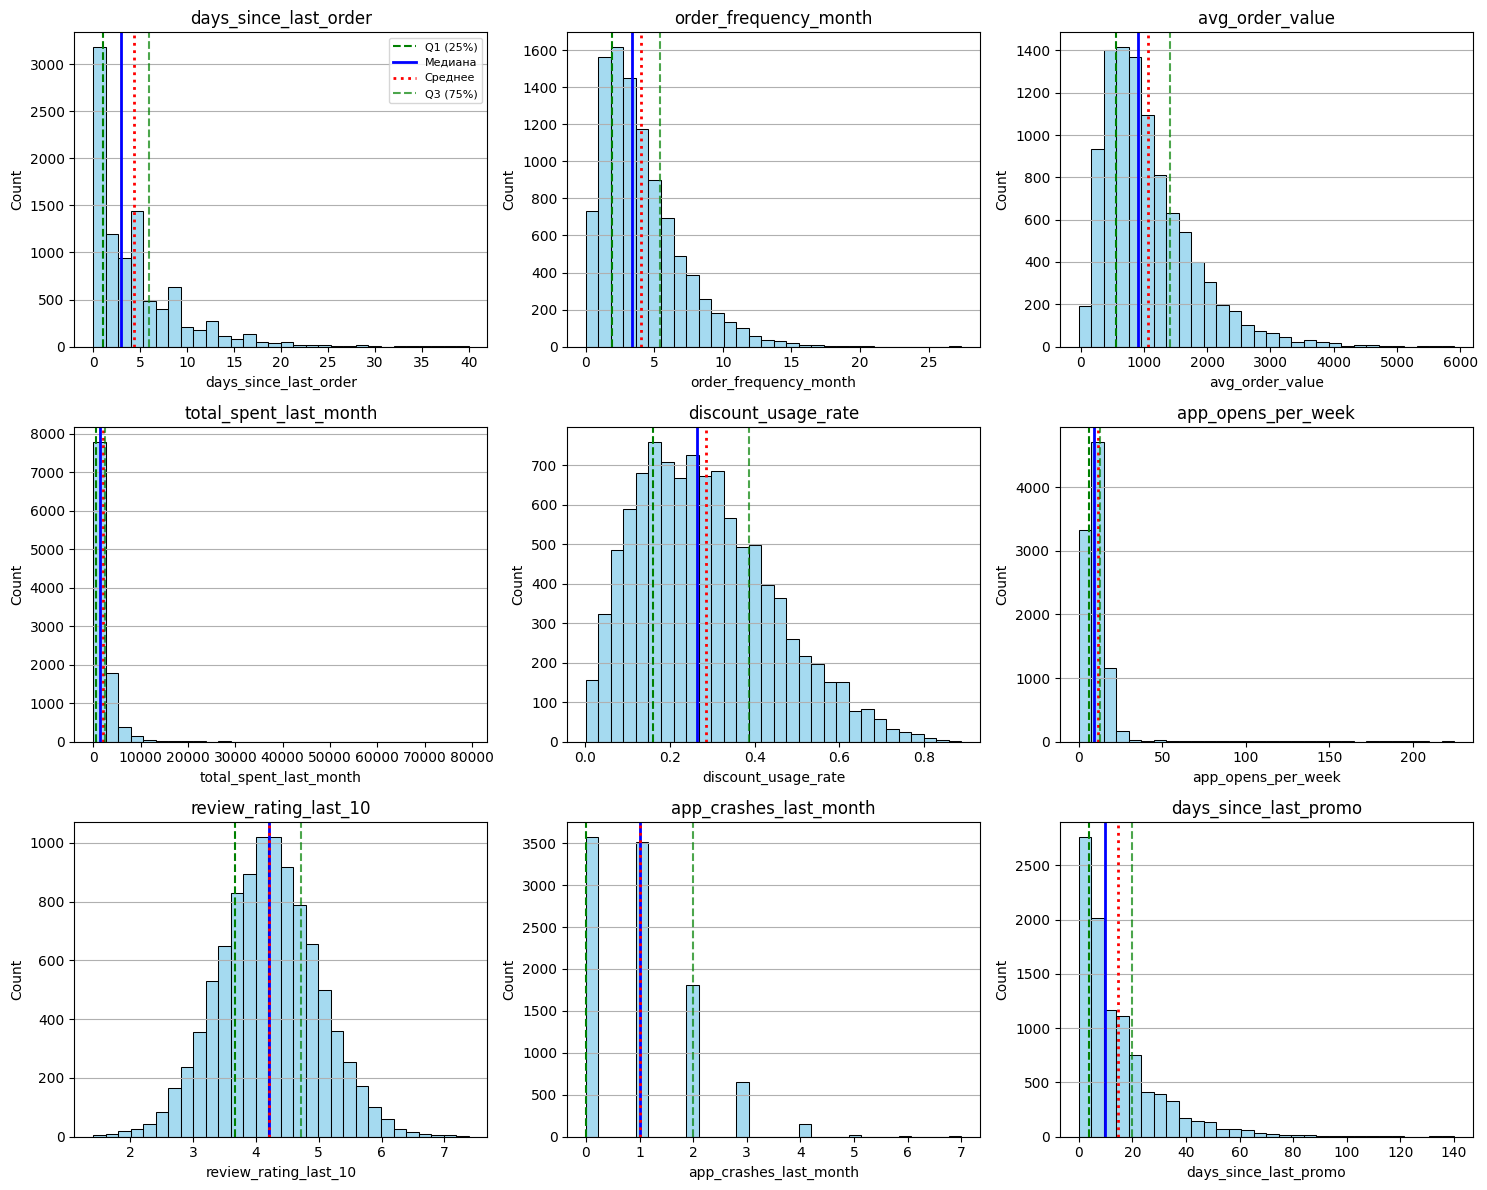

In [17]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    if col not in df.columns:
        continue
    
    ax = axes[idx]
    
    sns.histplot(data=df, x=col, kde=False, ax=ax, color='skyblue', bins=30, edgecolor='black')
    
    q1 = df[col].quantile(0.25)
    median = df[col].median()
    mean = df[col].mean()
    q3 = df[col].quantile(0.75)

    ax.axvline(q1, color='green', linestyle='--', linewidth=1.5, label='Q1 (25%)')
    ax.axvline(median, color='blue', linestyle='-', linewidth=2, label='Медиана')
    ax.axvline(mean, color='red', linestyle=':', linewidth=2, label='Среднее')
    ax.axvline(q3, color='green', linestyle='--', linewidth=1.5, label='Q3 (75%)', alpha=0.7)

    ax.set_title(f'{col}')
    ax.grid(axis='y')

    if idx == 0:
        ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()

In [18]:
def detect_outliers_iqr(df, columns):
    """Обнаружение выбросов методом межквартильного размаха (IQR)"""
    outliers_summary = []
    
    for col in columns:
        if col not in df.columns:
            continue
        
        data = df[col].dropna()
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers_count = ((data < lower_bound) | (data > upper_bound)).sum()
        outliers_pct = outliers_count / len(data) * 100
        
        outliers_summary.append({
            'Признак': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Нижняя граница': lower_bound,
            'Верхняя граница': upper_bound,
            'Выбросов': int(outliers_count),
            'Доля выбросов (%)': f"{outliers_pct:.2f}"
        })
    
    return pd.DataFrame(outliers_summary)

outliers_df = detect_outliers_iqr(df, numerical_cols)
outliers_df

,Признак,Q1,Q3,IQR,Нижняя граница,Верхняя граница,Выбросов,Доля выбросов (%)
0,days_since_last_order,1.000000,6.000000,5.000000,-6.500000,13.500000,561,5.90
1,order_frequency_month,1.937767,5.439363,3.501596,-3.314627,10.691756,302,3.07
2,avg_order_value,552.898663,1406.332153,853.433490,-727.251571,2686.482388,326,3.30
3,total_spent_last_month,629.680382,2481.650495,1851.970113,-2148.274787,5259.605664,594,5.85
4,discount_usage_rate,0.159884,0.387056,0.227172,-0.180874,0.727813,70,0.70
5,app_opens_per_week,6.313628,12.726649,6.413021,-3.305903,22.346181,355,3.72
6,review_rating_last_10,3.675543,4.717292,1.041749,2.112921,6.279915,89,0.91
7,app_crashes_last_month,0.000000,2.000000,2.000000,-3.000000,5.000000,7,0.07
8,days_since_last_promo,4.000000,20.000000,16.000000,-20.000000,44.000000,526,5.41


In [19]:
correlation_matrix = df[['order_frequency_month', 'order_frequency_week', 
            'avg_order_value', 'median_order_value',
            'total_spent_last_month', 'total_spent_last_week',
            'review_rating_last_10', 'review_rating_last_1',
            'churn']].phik_matrix(interval_cols=['order_frequency_month', 'order_frequency_week', 
                               'avg_order_value', 'median_order_value',
                               'total_spent_last_month', 'total_spent_last_week',
                               'review_rating_last_10', 'review_rating_last_1']
            )

print('Корреляционная матрица с коэффициентом phi_k для переменной churn')
weight_corr = correlation_matrix.loc[correlation_matrix.index != 'churn'][['churn']].sort_values(by='churn',
                                                                                                 ascending=False)
print(weight_corr)

Корреляционная матрица с коэффициентом phi_k для переменной churn
                           churn
order_frequency_week    0.080252
order_frequency_month   0.079332
total_spent_last_week   0.064183
total_spent_last_month  0.033998
review_rating_last_10   0.033943
avg_order_value         0.032515
review_rating_last_1    0.002342
median_order_value      0.000000


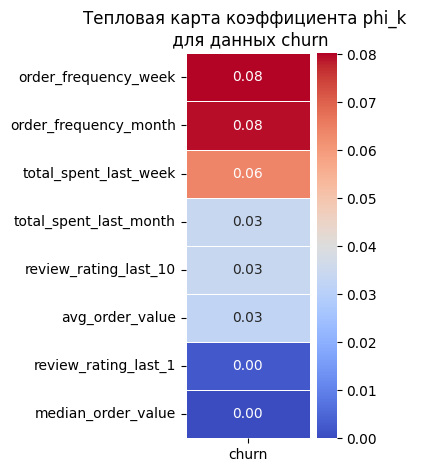


Самая сильная корреляция с рейтингом: order_frequency_week
Коэффициент Phi_k: 0.080


In [20]:
plt.figure(figsize=(2, 5))

data_heatmap = correlation_matrix[['churn']].loc[correlation_matrix.index != 'churn'].sort_values(by='churn',
                                                                                                  ascending=False)

sns.heatmap(
    data_heatmap,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    cbar=True
)
plt.title('Тепловая карта коэффициента phi_k \n для данных churn')
plt.show()

strongest_corr_row = weight_corr.iloc[0]
strongest_feature = weight_corr.index[0]
strongest_value = strongest_corr_row['churn']

print(f'\nСамая сильная корреляция с рейтингом: {strongest_feature}')
print(f'Коэффициент Phi_k: {strongest_value:.3f}')

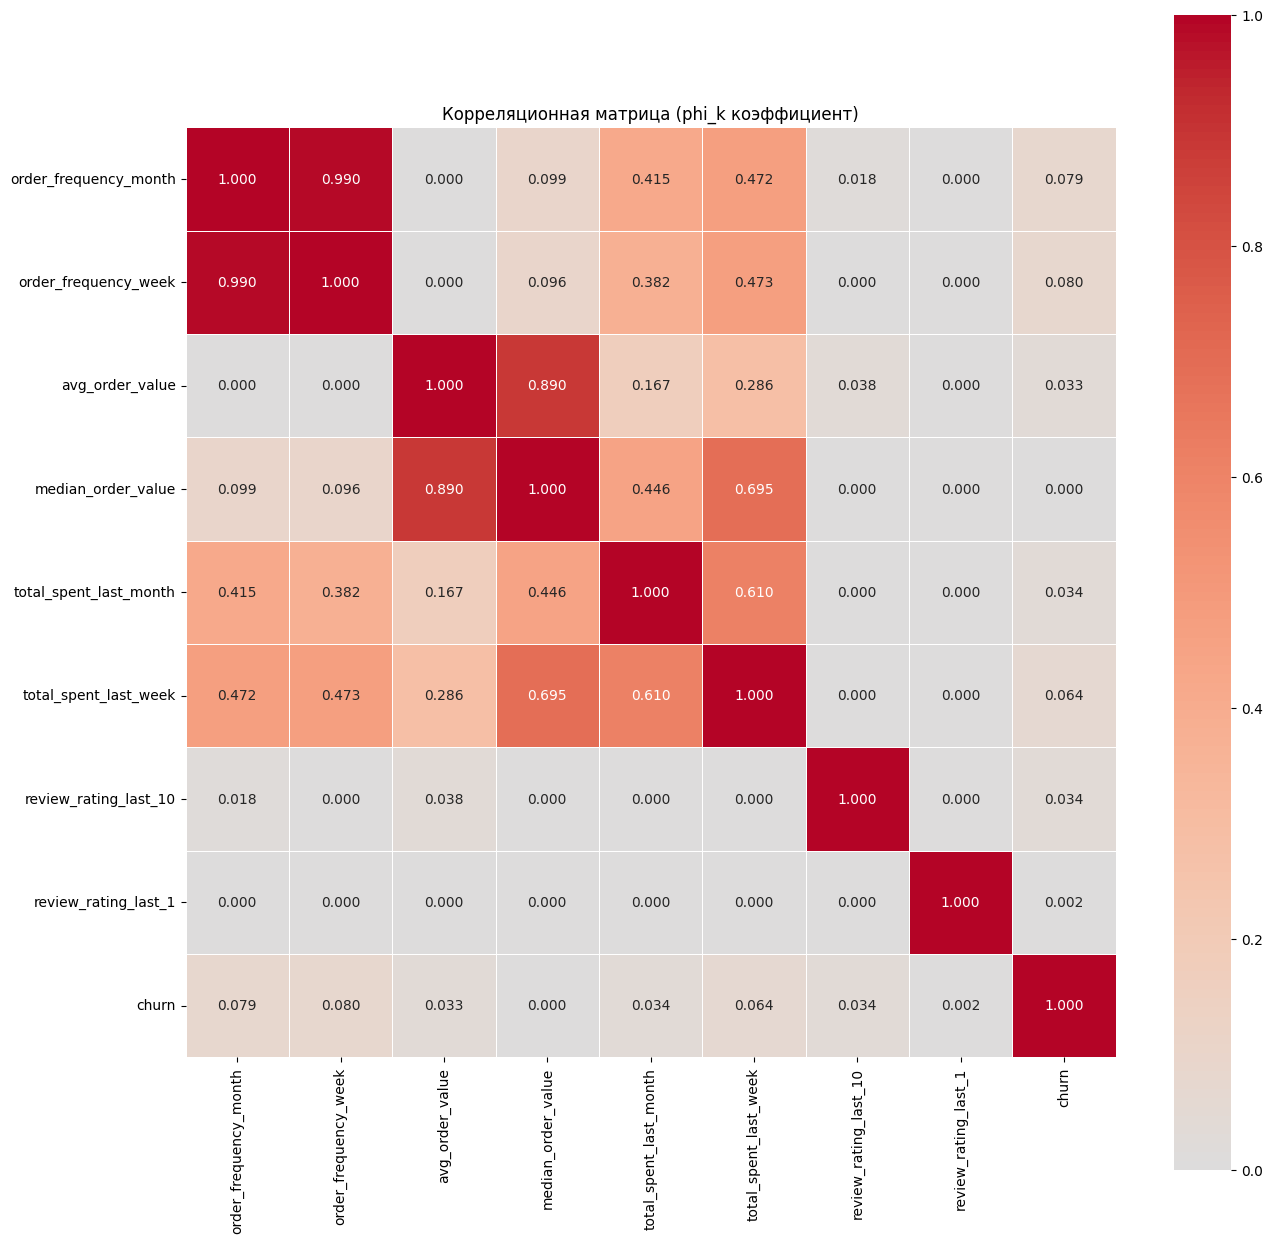

In [21]:
plt.figure(figsize=(15, 15))

sns.heatmap(correlation_matrix, 
            annot=True,
            fmt='.3f',
            linewidths=0.5,
            cbar=True,
            cmap='coolwarm',
            center=0,
            square=True,
            xticklabels=True,
            yticklabels=True)

plt.title('Корреляционная матрица (phi_k коэффициент)')
plt.show()

In [22]:
features_to_drop = [
    'user_id',
    'order_frequency_week',
    'median_order_value',
    'total_spent_last_week',
    'geo_location',
    'seasons'
]
df = df.drop(columns=features_to_drop)

# Проверяем результат
print(f"Было признаков: {dff.shape[1]}")
print(f"Осталось признаков: {df.shape[1]}")
print(f"Удалено признаков: {len(features_to_drop)}")

Было признаков: 27
Осталось признаков: 21
Удалено признаков: 6


### Промежуточный вывод:
**Дисбаланс:**
* Наблюдается сильный дисбаланс классов, так как количество лояльных пользователей - 94%, а ушедших 6%. 
* 25%, 50% и 75% перцентили равны 0, означает, что как минимум 75% наблюдений принадлежат классу 0. Это ещё одно подтверждение доминирования одного класса.

Следовательно необходимо использовать PR-AUC для оценки качества модели.


**Пропуски и дубликаты:**
* Наибольшее количество пропусков наблюдается в столбце `seasonal_menu_tried` (9.5%), в котором хранится, отметка о том, пробовал ли пользователь новейшее сезонное меню, наименьшее количество пропусков в `preferred_roast` - предпочитаемый тип обжарки;

*Стратегия заолнения пропусков:*
* Числовые признаки заменим медианой, так как она не искажает распределение так сильно, как среднее;
* Категориальные - модой или новым значением "неизвестно", так как такой признак возможен и пропуски могут быть информативными;
* Бинарные - также модой, так как можно предположить наиболее вероятное состояние.


* Дубликаты не найдены

**Категориальные признаки:**
* В категориальных признаков не так много категорий, поэтому One-Hot Encoding здесь отлично подойдет;
* Для генерации новых признаков можно придерживаться нескольких стратегий:
    1. Взаимодействие метрик. Клиент, который редко заказывает и давно не заходил — в зоне риска.
    2. Бинарные признаки легко интерпретировать в логистической регрессии, коэффициент покажет, насколько наличие флага увеличивает вероятность оттока.
* Категории в столбце `seasons` можно удалить, потому что он не несет информации об оттоке, а только указывает на текущее время.


**Выбросы:**
* По взуализации можно увидеть выбросы в признаках. Отрицательные значения в столбце `total_spent_last_month` говорят о возвратах средств или больших заказах, `days_since_last_promo` - низкая вовлеченность, так как клиенты не использовали промо больше 44 дней, отрицательные значения в суммах уазывают на ошибки в данных или опять же возвратах.

**Корреляция:**
* Пара признаков `order_frequency_month` и `order_frequency_week` имеют очень сильную корреляцию - 0.99, поэтому следует оставить один столбец, например `order_frequency_month`;
* Столбцы `avg_order_value` и `median_order_value`, также с большой корреляцией >0.8, можно также оставить один более сильный и устойчивый признак - `avg_order_value`
* `total_spent_last_month` и `total_spent_last_week` - корреляция больше 0.7. Оставим `total_spent_last_month`, так как он менее шумный;
* `user_id` - идентификатор пользователя не несет никакой информации для модели, возможно переобучение, поэтому удаляем столбец.
* Столбец `geo_location` имеет 100 уникальных значений, это усложнит работу с One-Hot Encoding, в таком случае присутствует риск переобучения - данный столбец следует удалить.

Линейные модели (LogisticRegression) чувствительны к мультиколлинеарности.

## Этап 3. Предобработка данных



In [23]:
X = df.drop(columns='churn')
y = df['churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, shuffle=True, random_state=RANDOM_STATE)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(8360, 20) (2090, 20) (8360,) (2090,)


In [24]:
numerical_features = [
    'days_since_last_order', 'order_frequency_month', 'avg_order_value',
    'total_spent_last_month', 'discount_usage_rate', 'seasonal_menu_tried',
    'app_opens_per_week', 'notifications_enabled', 'review_rating_last_10',
    'review_rating_last_1', 'app_crashes_last_month', 'days_since_last_promo',
    'coffee_preference_change'
]

categorical_features = [
    'last_coffee_type', 'preferred_roast', 'milk_preference',
    'coffee_bean_origin', 'last_drink_size', 'subscription_status',
    'phone_type'
]

In [25]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
])

In [26]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='error', drop='first', sparse=False))
])

In [27]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='drop')

In [28]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'Пропусков в train: {pd.isna(X_train_processed).sum()}')
print(f'Пропусков в test: {pd.isna(X_test_processed).sum()}')

Пропусков в train: 0
Пропусков в test: 0


/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


### Промежуточный вывод:
* Датасет разделен в проорции 80/20 с сохранением дисбаланса классов;
* Пропущенные значения обрабтаны: в числовых признаках заполнены медианой, в категориальных - модой.

## Этап 4. Обучение модели

In [29]:
model_basic = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000, 
    random_state=RANDOM_STATE
)

full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', model_basic)
])

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

In [30]:
scoring = ["neg_log_loss", "average_precision"]

enhanced_cv_results = cross_validate(
    estimator=full_pipeline,
    X=X_train,
    y=y_train,
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

cv_df = pd.DataFrame(enhanced_cv_results)
print('Результаты по фолдам кросс-валидации:')
print(cv_df.round(4))

print(f"\nСреднее значение по метрикам:")
print(f"Neg Log Loss: {-cv_df['test_neg_log_loss'].mean():.4f}")
print(f"Average Precision: {cv_df['test_average_precision'].mean():.4f}")

Результаты по фолдам кросс-валидации:
   fit_time  score_time  test_neg_log_loss  test_average_precision
0    0.1480      0.0335            -0.3385                  0.5615
1    0.1441      0.0351            -0.3213                  0.6353
2    0.1499      0.0355            -0.3228                  0.6206
3    0.1404      0.0363            -0.3138                  0.7178
4    0.1461      0.0376            -0.3078                  0.6360

Среднее значение по метрикам:
Neg Log Loss: 0.3208
Average Precision: 0.6342


/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: Fu

In [31]:
full_pipeline.fit(X_train, y_train)

y_pred_proba = full_pipeline.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, full_pipeline.predict(X_test))
baseline_roc_auc = roc_auc_score(y_test, full_pipeline.predict_proba(X_test)[:, 1])

print("Базовая модель:")
print(f"Accuracy: {baseline_accuracy:.3f}")
print(f"ROC-AUC: {baseline_roc_auc:.3f}")

/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Базовая модель:
Accuracy: 0.864
ROC-AUC: 0.931


### Примежуточный вывод:
* Average Precision = 0.63 - модель успешно выделяет пользователей, склонных к оттоку, даже на фоне сильного дисбаланса классов. Результат моедели только в 10 раз лучше случайного;
* Log Loss = 0.32 - ризкое значение указывает на хорошую калибровку вероятностей: модель не «переувёрена» в ошибочных прогнозах;
* Разброс PR-AUC: 0.56–0.72 — допустимый диапазон, модель не переобучается на отдельные подвыборки.

## Этап 5. Создание новых признаков

Новые признаки:

   - Извлечение квадратного корня поможет сгладить большие значения.

   - Возведение в квадрат усилит влияние больших значений.

In [32]:
X_train_enh = X_train.copy()
X_test_enh = X_test.copy()

X_train_enh['sqrt_total_spent'] = np.sqrt(np.maximum(X_train_enh['total_spent_last_month'], 0))
X_test_enh['sqrt_total_spent'] = np.sqrt(np.maximum(X_test_enh['total_spent_last_month'], 0))

X_train_enh['sq_order_freq'] = X_train_enh['order_frequency_month'] ** 2
X_test_enh['sq_order_freq'] = X_test_enh['order_frequency_month'] ** 2

In [33]:
numerical_features_2 = numerical_features + ['sqrt_total_spent', 'sq_order_freq']

num_pipe_2 = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe_2 = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

preprocessor_2 = ColumnTransformer([
    ('num', num_pipe_2, numerical_features_2),
    ('cat', cat_pipe_2, categorical_features)
], remainder='drop')

pipeline_2 = Pipeline([
    ('preprocessor', preprocessor_2),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

In [34]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["neg_log_loss", "average_precision"]

cv_results_2 = cross_validate(
    estimator=pipeline_2,
    X=X_train_enh,
    y=y_train,
    cv=cv_strategy,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("Сравнение метрик:\n")
print(f"Без новых признаков")
print(f"AP: {cv_df['test_average_precision'].mean():.4f} \nLogLoss: {-cv_df['test_neg_log_loss'].mean():.4f}")
print(f"\nС новыми признаками")
print(f"AP: {cv_results_2['test_average_precision'].mean():.4f}")
print(f"LogLoss: {-cv_results_2['test_neg_log_loss'].mean():.4f}")

/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


Сравнение метрик:

Без новых признаков
AP: 0.6342 
LogLoss: 0.3208

С новыми признаками
AP: 0.6354
LogLoss: 0.3206


/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [35]:
pipeline_2.fit(X_train_enh, y_train)

ohe = preprocessor_2.named_transformers_['cat'].named_steps['encoder']
cat_names = list(ohe.get_feature_names_out(categorical_features))
all_names = numerical_features_2 + cat_names

coefs = pipeline_2.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({'Признак': all_names, 'Вес': coefs, '|Вес|': np.abs(coefs)})
coef_df = coef_df.sort_values('|Вес|', ascending=False)

print("Топ-5 признаков по влиянию на отток:")
print(coef_df.head()[['Признак', 'Вес']])

Топ-5 признаков по влиянию на отток:
                     Признак       Вес
10    app_crashes_last_month  1.871212
39   subscription_status_pro  0.971413
1      order_frequency_month  0.617496
37  subscription_status_none -0.545242
21    milk_preference_almond  0.535743


/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [36]:
THRESHOLD = 0.05
significant = coef_df[coef_df['|Вес|'] > THRESHOLD]['Признак'].tolist()

print(f"Оставлено значимых признаков: {len(significant)}")
print(f"Удалено незначимых: {len(all_names) - len(significant)}")

Оставлено значимых признаков: 35
Удалено незначимых: 8


In [37]:
num_sig = [f for f in significant if f in numerical_features_2]
cat_sig = [f for f in significant if f in categorical_features]

final_preprocessor = ColumnTransformer([
    ('num', num_pipe_2, num_sig),
    ('cat', cat_pipe_2, cat_sig)
], remainder='drop')

final_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

In [38]:
final_cv = cross_validate(final_pipeline,
                          X_train_enh,
                          y_train,
                          cv=cv_strategy,
                          scoring=scoring,
                          n_jobs=-1)

print("Итоговое качество модели (после отбора признаков):")
print(f"Average Precision: {final_cv['test_average_precision'].mean():.4f}")
print(f"Neg Log Loss: {-final_cv['test_neg_log_loss'].mean():.4f}")

Итоговое качество модели (после отбора признаков):
Average Precision: 0.6459
Neg Log Loss: 0.3300


### Промежуточный вывоод:
* Добавлены новые признаки: `sqrt_total_spent` - извлечение квадратного корня из расходов за месяц. `sq_order_freq` - возведение частоты заказов в квадрат для усиления влияния аномально активных или пассивных пользователей;
* PR-AUC - ключевая метрика при дисбалансе. Её рост на 2% говорит о том, что модель стала лучше ранжировать пользователей, склонных к оттоку;
* Небольшой рост Log Loss после отбора признаков говорит о том, что модель стала менее уверенной в шумах, но это компенсируется улучшением ранжирования миноритарного класса.

## Этап 6. Эксперименты с гиперпараметрами

In [39]:
C_values = [0.01, 0.1, 1.0, 10.0]
results = []

for c_val in C_values:
    pipe = Pipeline([
        ('preprocessor', preprocessor_2),
        ('model', LogisticRegression(C=c_val, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
    ])
    
    cv_res = cross_validate(
        pipe, X_train_enh, y_train,
        cv=cv_strategy,
        scoring=['average_precision', 'neg_log_loss'],
        return_train_score=False,
        n_jobs=-1
    )
    
    results.append({
        'C': c_val,
        'AP_mean': cv_res['test_average_precision'].mean(),
        'LogLoss_mean': -cv_res['test_neg_log_loss'].mean()
    })
    
res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: Fu

    C  AP_mean  LogLoss_mean
 0.01 0.651699      0.326293
 0.10 0.639516      0.320181
 1.00 0.635425      0.320628
10.00 0.634663      0.320714


/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(
/Users/admin/Desktop/Проекты DS/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:868: Fu

In [40]:
best_c = res_df.loc[res_df['AP_mean'].idxmax(), 'C']
best_pipeline = Pipeline([
    ('preprocessor', preprocessor_2),
    ('model', LogisticRegression(C=best_c, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])
print(f"Лучшее значение C: {best_c}")

Лучшее значение C: 0.01


### Промежуточный вывод:
* Максимальный Pecision достигается при самой сильной регуляризации (C=0.01), хотя должно происходить обратное, это говорит о том, что в данных присутствует шум или мультиколлинеарность признаков, и сглаживание весов помогает модели лучше ранжировать объекты;
* При C=0.01 LogLoss хуже на 0.006 по сравнению с C=0.1. Это означает, что предсказанные вероятности становятся менее точными, но порядок объектов более корректным.
* Метрики практически не меняются в диапазоне [0.1; 10];
* Оптимальное значение: C = 0.01 - корректно, так как максимизирует целевую метрику Precision (+0.012 относительно базовой конфигурации C=1.0).

## Этап 7. Подготовка финальной модели


In [41]:
final_pipeline = Pipeline([
    ('preprocessor', final_preprocessor),
    ('model', LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
])

In [42]:
final_pipeline.fit(X_train_enh, y_train)

y_test_proba = final_pipeline.predict_proba(X_test_enh)[:, 1]

In [43]:
test_ap = average_precision_score(y_test, y_test_proba)
test_logloss = log_loss(y_test, y_test_proba)

print(f'Финальное качество на тестовой выборке:')
print(f'Average Precision: {test_ap:.4f}')
print(f'Log Loss: {test_logloss:.4f}')

Финальное качество на тестовой выборке:
Average Precision: 0.6998
Log Loss: 0.3359


### Промежуточный вывод:
* Precision на тесте выше, чем на кросс-валидации (+4.8), это говорит о том, что модель не переобучилась и хорошо обобщает закономерности;
* Log Loss немного ухудшился, разница составляет +0.0096;
* Модель позволяет выделить примерно 10-20% клиентов с наибольшим риском оттока для приоритетного удержания.

## Этап 8. Отчёт о проделанной работе

В ходе проекта была построена и оптимизирована модель прогнозирования оттока клиентов на базе логистической регрессии.
* Базовая модель показала хорошую разделяющую способность (на тесте ROC-AUC: 0.931). AP 0.6332 - модель лучше случайного угадывания на 63%, LogLoss показал умеренную ошибку в оценке вероятностей;
* После добавления новых признаков был минимальный прирост. Это подтверждает, что основные закономерности в данных носят линейный характер, а нелинейные слегка сглаживают выбросы, не меняя общую структуру признаков.;
* Сильная L2-регуляризация не допустила переобучения, максимизировав ранжирующую способность;
* Финальный тест: AP = 0.6998 (+6.7 относительно базовой версии), LogLoss = 0.3359. Прирост метрики на отложенных данных относительно кросс-валидации говорят об отсутствии переобучения и устойчивости модели к новым данным.


Наиболее важные факторы:
* Был произведен отбор признаков по весам коэффициентам;
* Усиленная регуляризация, не допустила переобучения. Вместо усложнения модели, сглаживание весов обеспечило оптимальный баланс смещения и дисперсии, максимизировав ранжирующую способность при сохранении стабильности.

## Этап 9. Сохранение модели для продакшена

In [44]:
with open('logrreg_model.pkl', 'wb') as file:
    pickle.dump(final_pipeline, file)
print("Модель сохранена в файл 'logrreg_model.pkl'")

Модель сохранена в файл 'logrreg_model.pkl'


In [45]:
with open('logrreg_model.pkl', 'rb') as file:
    loaded_pipeline = pickle.load(file)
print("Модель загружена из файла!")

Модель загружена из файла!


In [46]:
y_pred_proba = loaded_pipeline.predict_proba(X_test_enh)[:, 1]
y_pred = loaded_pipeline.predict(X_test_enh)

ap_test = average_precision_score(y_test, y_pred_proba)
ll_test = log_loss(y_test, y_pred_proba)

print(f"Метрики на тесте после загрузки:")
print(f"Average Precision: {ap_test:.4f}")
print(f"Log Loss: {ll_test:.4f}")

Метрики на тесте после загрузки:
Average Precision: 0.6998
Log Loss: 0.3359


In [47]:
predictions = loaded_pipeline.predict(X_train_enh[:5])
print(f"Предсказания для первых 5 объектов: {predictions}")

Предсказания для первых 5 объектов: [0 0 0 0 0]


In [48]:
from IPython.display import FileLink
FileLink('logrreg_model.pkl')

/Users/admin/Desktop/Проекты DS/logrreg_model.pkl

Ссылка: https://k8s.jupyterhub.praktikum-services.ru/user/user-0-1959189601/notebooks/logrreg_model.pkl